# Demographic, economic and crime correlations — Mexico City

**Author: Lorena Pérez · Phase 3 · TEAM_PLAN §4.4**

The primary analysis uses city-core urban AGEBs with fewer than 100 residents excluded. Pairwise-complete Pearson and Spearman tests are compared for three planned relationships. Distribution normality and Tukey-IQR outlier counts are checked for both variables in every pair. A second run includes low-population AGEBs to assess rate sensitivity. Results are descriptive associations, not causal effects.

All observations are loaded from the warehouse KPI view through `src.analysis.data.load_kpis`; the crime KPIs are based on the available January–July 2024 investigation-file snapshot.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src/analysis/data.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the repository root containing src/analysis/data.py")
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.data import load_kpis

In [2]:
pairs = [
    ("pop_density_km2", "business_density_km2", "Population density vs business density"),
    ("crime_rate_per_1k", "businesses_per_1k", "Crime rate vs businesses per 1,000 residents"),
    ("pea_rate", "crime_rate_per_1k", "Economically active population rate vs crime rate"),
]

primary = load_kpis(city_core_only=True, exclude_low_population=True)
including_low_population = load_kpis(city_core_only=True, exclude_low_population=False)
assert primary.crs.to_epsg() == 6372, f"Expected EPSG:6372, got {primary.crs}"
figures_dir = PROJECT_ROOT / "outputs/figures"
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Primary sample: {len(primary):,} AGEBs; sensitivity sample: {len(including_low_population):,} AGEBs")

Primary sample: 2,297 AGEBs; sensitivity sample: 2,348 AGEBs


In [3]:
def iqr_outlier_count(values):
    q1, q3 = values.quantile([0.25, 0.75])
    spread = q3 - q1
    return int(((values < q1 - 1.5 * spread) | (values > q3 + 1.5 * spread)).sum())


def analyse_pairs(frame, sample_label):
    results = []
    for x_col, y_col, label in pairs:
        pair = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(pair) < 8:
            raise ValueError(f"Only {len(pair)} complete observations for {label}; at least 8 are needed")
        x, y = pair[x_col], pair[y_col]
        x_normality = stats.normaltest(x).pvalue
        y_normality = stats.normaltest(y).pvalue
        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)
        results.append({
            "sample": sample_label,
            "relationship": label,
            "n": len(pair),
            "pearson_r": pearson.statistic,
            "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic,
            "spearman_p": spearman.pvalue,
            "x_normality_p": x_normality,
            "y_normality_p": y_normality,
            "x_iqr_outliers": iqr_outlier_count(x),
            "y_iqr_outliers": iqr_outlier_count(y),
        })
    return pd.DataFrame(results)


primary_results = analyse_pairs(primary, "low-population excluded")
sensitivity_results = analyse_pairs(including_low_population, "including low-population")
results = pd.concat([primary_results, sensitivity_results], ignore_index=True)
display(results.round(5))
print("Normality p-values use D’Agostino-Pearson; small values indicate departure from normality.")
print("Outliers are observations beyond 1.5 × IQR. Every coefficient and p-value uses its pairwise-complete n.")

,sample,relationship,n,pearson_r,pearson_p,spearman_rho,spearman_p,x_normality_p,y_normality_p,x_iqr_outliers,y_iqr_outliers
0,low-population excluded,Population density vs business density,2297,0.09925,0.0,0.35837,0.0,0.0,0.0,42,95
1,low-population excluded,"Crime rate vs businesses per 1,000 residents",2297,0.79412,0.0,0.57985,0.0,0.0,0.0,228,193
2,low-population excluded,Economically active population rate vs crime rate,2297,0.20930,0.0,0.19023,0.0,0.0,0.0,97,228
3,including low-population,Population density vs business density,2348,0.10935,0.0,0.37811,0.0,0.0,0.0,39,97
4,including low-population,"Crime rate vs businesses per 1,000 residents",2331,0.49032,0.0,0.58926,0.0,0.0,0.0,252,210
5,including low-population,Economically active population rate vs crime rate,2321,0.12185,0.0,0.17872,0.0,0.0,0.0,98,244


Normality p-values use D’Agostino-Pearson; small values indicate departure from normality.
Outliers are observations beyond 1.5 × IQR. Every coefficient and p-value uses its pairwise-complete n.


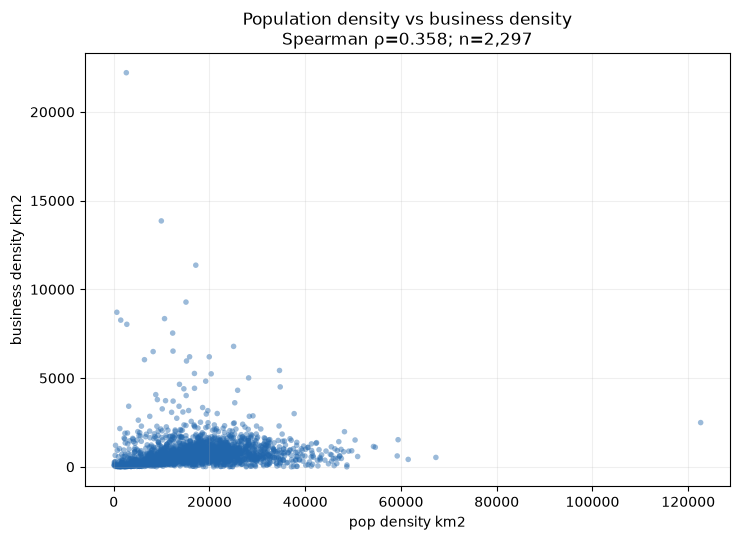

Saved outputs/figures/31_correlation_pop_density_km2_vs_business_density_km2.png


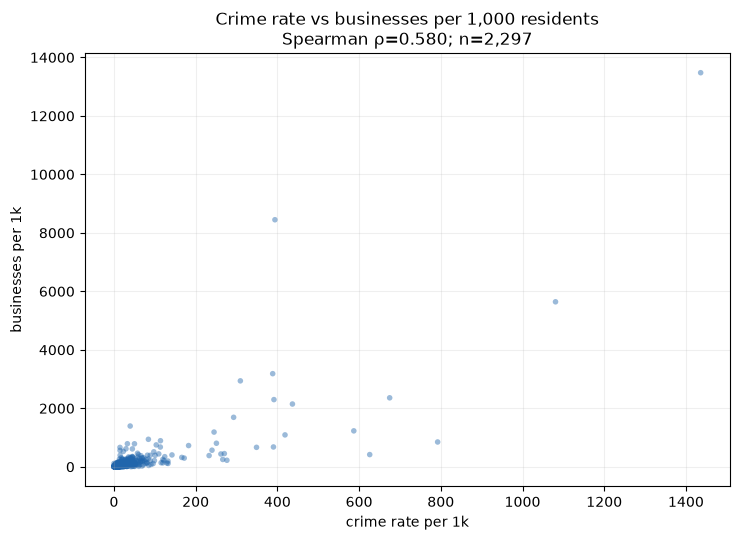

Saved outputs/figures/31_correlation_crime_rate_per_1k_vs_businesses_per_1k.png


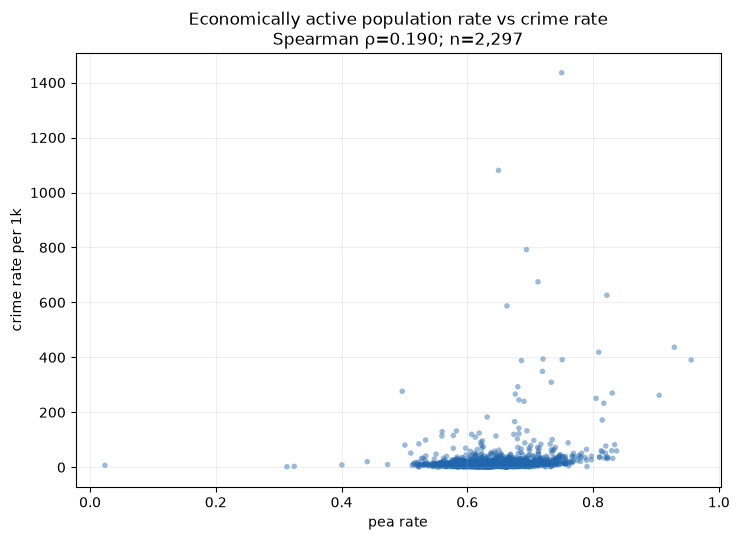

Saved outputs/figures/31_correlation_pea_rate_vs_crime_rate_per_1k.png
Saved outputs/figures/31_correlation_results.csv


In [4]:
for x_col, y_col, label in pairs:
    pair = primary[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    rho = stats.spearmanr(pair[x_col], pair[y_col]).statistic
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(pair[x_col], pair[y_col], s=16, alpha=0.45, color="#2166ac", edgecolors="none")
    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))
    ax.set_title(f"{label}\nSpearman ρ={rho:.3f}; n={len(pair):,}")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    path = figures_dir / f"31_correlation_{x_col}_vs_{y_col}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved {path.relative_to(PROJECT_ROOT).as_posix()}")

results_path = figures_dir / "31_correlation_results.csv"
results.to_csv(results_path, index=False)
print(f"Saved {results_path.relative_to(PROJECT_ROOT).as_posix()}")

## Interpretation

### Why use Spearman as the primary association

In the primary sample, all six marginal normality tests reject normality (D’Agostino–Pearson p-values: population density 3.080616086961255e-143, business density 0.0; crime rate and businesses per 1,000 residents 0.0 for both; PEA rate 4.600382592922818e-106, crime rate 0.0). The 1.5×IQR checks find 42 and 95 outliers for population and business density, 228 and 193 for crime rate and businesses per 1,000 residents, and 97 and 228 for PEA and crime rate. The scatterplots show heavy right tails and influential extremes. Spearman is therefore the more representative primary summary of monotone rank association; Pearson is retained as a comparison of linear association and its sensitivity to extreme magnitudes. A p-value shown as 0.0 is floating-point underflow, not a probability exactly equal to zero.

### Results: low-population AGEBs excluded (primary)

- **Population density vs business density** — pairwise n=2,297; Pearson r=0.09925326052007577, p=1.8782907700671607e-06; Spearman ρ=0.3583660355219703, p=1.4619184814949416e-70. The positive rank association is materially stronger than the weak linear coefficient, consistent with a positive but nonlinear/uneven monotone relationship rather than a close straight-line fit.
- **Crime rate per 1,000 vs businesses per 1,000** — pairwise n=2,297; Pearson r=0.7941165078671001, p=0.0; Spearman ρ=0.5798466062982711, p=1.6942435682739205e-206. Both are positive, but the smaller rank coefficient shows how extreme rates inflate the linear association; the practical result is a strong positive ordering, not evidence of a proportional linear relationship.
- **PEA rate vs crime rate per 1,000** — pairwise n=2,297; Pearson r=0.2092974107094606, p=3.7459758048549746e-24; Spearman ρ=0.19022993221052126, p=3.7052625004852245e-20. Both coefficients indicate a weak positive association; its small magnitude matters more practically than statistical significance at this sample size.

### Sensitivity: low-population AGEBs included

- **Population density vs business density** — pairwise n=2,348; Pearson r=0.10934875123449674, p=1.085868406249431e-07; Spearman ρ=0.3781133860783547, p=1.1028121645040284e-80. Both remain positive and increase slightly (Pearson +0.01009549071442097; Spearman +0.0197473505563844); the conclusion of a modest positive rank association is unchanged.
- **Crime rate per 1,000 vs businesses per 1,000** — pairwise n=2,331; Pearson r=0.4903205935583834, p=2.876819743520374e-141; Spearman ρ=0.5892638002038433, p=5.425904584167309e-218. The pairwise n is below 2,348 because undefined per-capita rates are excluded. The Pearson coefficient drops by 0.3037959143087167 while Spearman increases by 0.0094171939055722; the positive rank association remains moderately strong, but the linear magnitude is highly sensitive to small-population denominators.
- **PEA rate vs crime rate per 1,000** — pairwise n=2,321; Pearson r=0.12184767570311028, p=3.884965083712161e-09; Spearman ρ=0.17872162781996107, p=4.116409311914616e-18. The pairwise n is below 2,348 because PEA or crime rates are undefined for some zero-denominator AGEBs. Both coefficients remain positive but weaken (Pearson −0.08744973500635032; Spearman −0.01150830489056019); the association remains weak, so the practical conclusion does not change.

### Shared population denominator

`crime_rate_per_1k` and `businesses_per_1k` are both `1000 × count / pop_total` (`sql/03_views.sql`). Dividing two counts by the same resident population induces a positive correlation even when the counts are unrelated: a commercial AGEB with few residents gets a high value on both axes at once. The strongest Pearson coefficient (r=0.794) is therefore partly a ratio artifact and must not be read as the strength of the link between business activity and recorded crime. The rank coefficient is less exposed to these extremes, and the sensitivity run shows the linear coefficient moving by 0.30 when low-population AGEBs enter the sample. Comparisons that avoid the shared denominator, such as raw counts or per-km² densities, are the appropriate check before quoting this relationship.

These results describe associations among AGEB-level indicators and do not show that business activity or demographic composition causes recorded crime. Ordinary Pearson and Spearman p-values assume independent observations and do not correct for the spatial dependence documented elsewhere in this project; treat the reported significance as unadjusted, non-spatial evidence.